In [1]:
target_cols = 'K_Rho'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import os

input_folder=f'C:/Users/1/projects/zadachi/2 задача/{target_cols} random'
output_file=f'{target_cols} random.csv'
columns = ['K_Nu', 'K_E', 'K_Rho', 'K_incl', 'F', 'K_lambda_r', 'A2', 'А2_surface',  'Nu_host medium', 'E', 'Rho', 'Vp', 'Vs', 'Z']

C:\Users\1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
def merge_txt_files_to_dataset():
    all_data = []

    for filename in os.listdir(input_folder):
        if filename.endswith('.txt'):
            filepath = os.path.join(input_folder, filename)
            df = pd.read_csv(filepath, sep='\s+', header=None, names=columns)

            all_data.append(df)

    combined_df = pd.concat(all_data, ignore_index=True)
    combined_df.to_csv(output_file, index=False)
    print(f"Датасет сохранен в {output_file} (строк: {len(combined_df)})")

# Пример использования

merge_txt_files_to_dataset()

Датасет сохранен в K_Rho random.csv (строк: 100100)


In [4]:
df = pd.read_csv(output_file)
df[:5]

,K_Nu,K_E,K_Rho,K_incl,F,K_lambda_r,A2,А2_surface,Nu_host medium,E,Rho,Vp,Vs,Z
0,1,1,1.98177,1,0.1,10.000000,5.331373e-13,5.331413e-13,0.25,5.000000e+10,2700,3348.629649,1933.332229,2502.294446
1,1,1,1.98177,1,0.2,5.000000,5.334628e-13,5.331372e-13,0.25,5.000000e+10,2700,3348.629649,1933.332229,2502.294446
2,1,1,1.98177,1,0.3,3.333333,5.366540e-13,5.363021e-13,0.25,5.000000e+10,2700,3348.629649,1933.332229,2502.294446
3,1,1,1.98177,1,0.4,2.500000,5.331394e-13,5.333450e-13,0.25,5.000000e+10,2700,3348.629649,1933.332229,2502.294446
4,1,1,1.98177,1,0.5,2.000000,5.325957e-13,5.328923e-13,0.25,5.000000e+10,2700,3348.629649,1933.332229,2502.294446


In [5]:
df['A2/A2_s'] = df['A2'] / df['А2_surface']
y = df[target_cols]
X = df[['A2/A2_s', 'F']]

In [6]:
scaler_X = StandardScaler()

X_scaled = scaler_X.fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [8]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(2,), name='hidden_layer_1'),
    Dropout(0.2),  # Добавляем Dropout для регуляризации
    Dense(64, activation='relu', name='hidden_layer_2'),
    Dropout(0.2),
    Dense(1, name='output_layer')
])

C:\Users\1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Ранняя остановка для предотвращения переобучения
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Обучение модели
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.1049 - mae: 0.2402 - val_loss: 0.0507 - val_mae: 0.1387
Epoch 2/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0658 - mae: 0.1835 - val_loss: 0.0487 - val_mae: 0.1404
Epoch 3/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.0576 - mae: 0.1662 - val_loss: 0.0426 - val_mae: 0.1232
Epoch 4/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0523 - mae: 0.1549 - val_loss: 0.0405 - val_mae: 0.1138
Epoch 5/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.0494 - mae: 0.1484 - val_loss: 0.0395 - val_mae: 0.1203
Epoch 6/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0471 - mae: 0.1437 - val_loss: 0.0388 - val_mae: 0.1194
Epoch 7/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0463 - mae: 0.1416 - val_loss: 0.0352 - val_mae: 0.1049
Epoch 8/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0446 - mae: 0.1389 - val_loss: 0.0341 - val_mae: 0.0999
Epoch 9/100
2002/2002 ━━

In [12]:
y_pred= np.array(model.predict(X_test)).flatten()
y_test = np.array(y_test)
y_test, y_pred

626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(array([0.5516  , 0.736584, 1.28929 , ..., 1.90423 , 0.860429, 0.523897]),
 array([0.59264666, 0.7435767 , 1.2644275 , ..., 1.2774802 , 0.8351865 ,
        0.6181493 ], dtype=float32))

In [13]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
relative_errors = np.abs((y_test - y_pred) / y_test) * 100
mean_relative_error = np.mean(relative_errors)
std_relative_error = np.std(relative_errors)

In [14]:

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ МОДЕЛИ")
print("="*50)
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Absolute Per Error (MAPE): {mape:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R² Score: {r2:.6f}")


РЕЗУЛЬТАТЫ МОДЕЛИ
Mean Squared Error (MSE): 0.026560
Mean Absolute Error (MAE): 0.080257
Mean Absolute Per Error (MAPE): 0.077217
Root Mean Squared Error (RMSE): 0.162973
R² Score: 0.861784


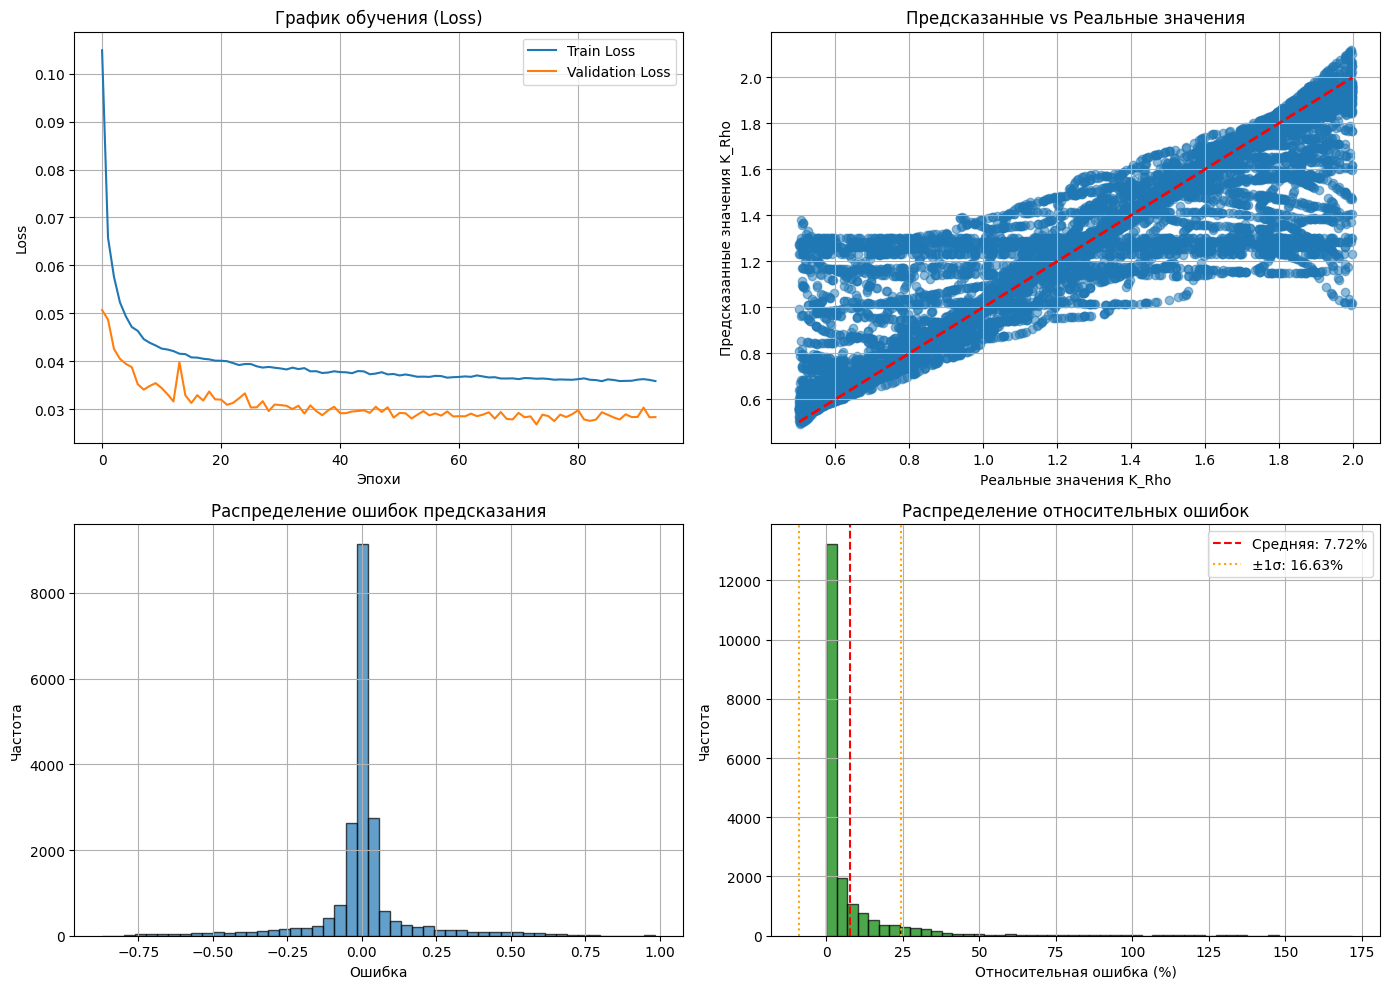


ДЕТАЛЬНАЯ СТАТИСТИКА
Минимальная относительная ошибка: 0.00%
Максимальная относительная ошибка: 171.84%
Медианная относительная ошибка: 1.78%
25-й перцентиль: 0.76%
75-й перцентиль: 6.38%

ПРИМЕРЫ ПРЕДСКАЗАНИЙ (первые 10 тестовых образцов)
 Реальный K_Rho  Предсказанный K_Rho  Абсолютная ошибка  Относительная ошибка (%)
       0.551600             0.592647           0.041047                  7.441381
       0.736584             0.743577           0.006993                  0.949343
       1.289290             1.264428           0.024862                  1.928384
       1.660920             1.695544           0.034624                  2.084614
       1.704830             1.610255           0.094575                  5.547495
       1.438420             1.402024           0.036396                  2.530258
       0.578145             0.781828           0.203683                 35.230412
       1.398460             1.398723           0.000263                  0.018832
       1.820480      

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. График обучения
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('График обучения (Loss)')
axes[0, 0].set_xlabel('Эпохи')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Сравнение предсказанных и реальных значений
axes[0, 1].scatter(y_test, y_pred, alpha=0.5)
axes[0, 1].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_title('Предсказанные vs Реальные значения')
axes[0, 1].set_xlabel(f'Реальные значения {target_cols}')
axes[0, 1].set_ylabel(f'Предсказанные значения {target_cols}')
axes[0, 1].grid(True)

# 3. Распределение ошибок
errors = y_test.flatten() - y_pred.flatten()
axes[1, 0].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Распределение ошибок предсказания')
axes[1, 0].set_xlabel('Ошибка')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].grid(True)

#
# 4. Распределение относительных ошибок
axes[1, 1].hist(relative_errors, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].axvline(mean_relative_error, color='red', linestyle='--', 
                   label=f'Средняя: {mean_relative_error:.2f}%')
axes[1, 1].axvline(mean_relative_error + std_relative_error, color='orange', 
                   linestyle=':', label=f'±1σ: {std_relative_error:.2f}%')
axes[1, 1].axvline(mean_relative_error - std_relative_error, color='orange', linestyle=':')
axes[1, 1].set_title('Распределение относительных ошибок')
axes[1, 1].set_xlabel('Относительная ошибка (%)')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Дополнительная статистика
print("\n" + "="*50)
print("ДЕТАЛЬНАЯ СТАТИСТИКА")
print("="*50)
print(f"Минимальная относительная ошибка: {relative_errors.min():.2f}%")
print(f"Максимальная относительная ошибка: {relative_errors.max():.2f}%")
print(f"Медианная относительная ошибка: {np.median(relative_errors):.2f}%")
print(f"25-й перцентиль: {np.percentile(relative_errors, 25):.2f}%")
print(f"75-й перцентиль: {np.percentile(relative_errors, 75):.2f}%")


# Примеры предсказаний
print("\n" + "="*50)
print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ (первые 10 тестовых образцов)")
print("="*50)
examples = pd.DataFrame({
    f'Реальный {target_cols}': y_test.flatten()[:10],
    f'Предсказанный {target_cols}': y_pred.flatten()[:10],
    'Абсолютная ошибка': np.abs(y_test.flatten()[:10] - y_pred.flatten()[:10]),
    'Относительная ошибка (%)': relative_errors.flatten()[:10]
})
print(examples.to_string(index=False))

# Сохранение модели
model.save(f'{target_cols}_prediction_model.h5')
print("\nМодель сохранена")

In [16]:
accuracy_5_percent = np.mean(relative_errors < 5) * 100
print(f"Процент предсказаний с ошибкой < 5%: {accuracy_5_percent:.2f}%")

Процент предсказаний с ошибкой < 5%: 71.79%
